Title: Annual_tas.ipynb

Purpose: Determine the time period for different warming levels for different ESMs

Author: Onno Nennecke on 14.01.2026 Modified: 14.01.2026

Input data: 

- tas ann ts
    - This file lies here: /climca/data/cmip6-ng/tas/ann/native

Output data:

- 
    - This file lies here: 


In [20]:
import xarray as xr
import pandas as pd
import glob
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [21]:
# Example: tas_ann_ACCESS-CM2_ssp370_r1i1p1f1_native.nc
def parse_filename(fname):
    parts = fname.replace(".nc", "").split("_")
    esm = parts[2]
    run = parts[4]
    return esm, run


In [22]:
def global_lat_weighted_mean(da):
    """
    Compute latitude-weighted global mean of a DataArray
    """
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    da_K = da.weighted(weights).mean(dim=("lat", "lon"))
    da_C = da_K - 273.15  # Convert from Kelvin to Celsius
    return da_C


In [23]:
def adjust_gmt(gmt):
    baseline = gmt.sel(
        time=slice("1995-01-01", "2014-12-31")
    ).mean(dim="time")

    return gmt - baseline + 0.85

# Example usage:
# adjusted_gmt = adjust_gmt(esm_timeseries['ACCESS-CM2'])

# Orignal
# def adjust_gmt(self):
# 	self.values -= self.values.loc[:,1995:2014].mean('year')
# 	self.values += 0.85

In [ ]:
# Calculate ERA5 global mean temperature (probably not needed)

era5_data_dir = Path("/climca/data/ERA5/daily/t2m")

# Read all era5 .nc files with the years 1995 -2014
nc_files = glob.glob(str(era5_data_dir / "*.nc"))
nc_files_selected = [f for f in nc_files if any(str(year) in f for year in range(1995, 2015))]
nc_files_selected.sort()

# Open all datasets together
ds_era5 = xr.open_mfdataset(nc_files_selected, combine='by_coords')

# Calculate annual mean temperature
ds_era5_ann = ds_era5.resample(time='YE').mean()

ds_era5_ann

# Calculate global mean temperature
ds_era5_gmt = global_lat_weighted_mean(ds_era5_ann['var167'])

ds_era5_gmt.load()

In [ ]:
ds_era5_gmt.mean(dim='time').item()

14.338343270312581

In [61]:
# Calculate ERA5 global mean temperature (probably not needed)

# Read all era5 .nc files with the years 1995 -2014
nc_files_selected_new = [f for f in nc_files if any(str(year) in f for year in range(2015, 2025))]
nc_files_selected_new.sort()

# Open all datasets together
ds_era5_new = xr.open_mfdataset(nc_files_selected_new, combine='by_coords')

# Calculate annual mean temperature
ds_era5_new_ann = ds_era5_new.resample(time='YE').mean()

ds_era5_new_ann

# Calculate global mean temperature
ds_era5_new_gmt = global_lat_weighted_mean(ds_era5_new_ann['var167'])

ds_era5_new_gmt.load()

<xarray.DataArray 'var167' (time: 10)> Size: 80B
array([14.63662031, 14.81410783, 14.72346043, 14.6443953 , 14.78024227,
       14.80665719, 14.65553932, 14.68195283, 14.98287748, 15.09497046])
Coordinates:
  * time     (time) datetime64[ns] 80B 2015-12-31 2016-12-31 ... 2024-12-31

In [64]:
ds_era5_new_gmt.mean(dim='time').item() - ds_era5_gmt.mean(dim='time').item() + 0.85

1.2937390706854246

In [51]:
# Calculate Warming for ERA5
ds_era5_gmt_adjusted = ds_era5_gmt.mean(dim='time').item() - 0.85
ds_era5_gmt_adjusted

13.488343270312582

In [24]:
# Directory containing the NetCDF files
data_dir = Path("/climca/data/cmip6-ng/tas/ann/native")

ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3',
        'GFDL-ESM4', 'MPI-ESM1-2-HR', 
        'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']

In [25]:
# Check if all ESMs are present in the data directory for ssp370 scenario and create a list of files per ESM
esms = set()
files = []
esm_files = defaultdict(list)


for file in data_dir.glob("*.nc"):
    name = file.name
    
    if "ssp370" in name and any(esm in name for esm in ESMs):
        esm, run = parse_filename(name)
        if esm in ESMs:
            esms.add(esm)
            files.append(name)
            esm_files[esm].append(name)
            

# Convert to sorted list if desired
esms = sorted(esms)
files = sorted(files)
# esm_files = sorted(esm_files)

print("ESMs found for ssp370:")
for esm in esms:
    print(esm)

print(f"\nTotal files found for ssp370: {len(files)}\n")

# Count how many files per ESM
print("File count per ESM:")

file_counts = {esm: 0 for esm in ESMs}
file_counts
for f in files:
    esm, run = parse_filename(f)
    if esm in file_counts:
        file_counts[esm] += 1

print(file_counts)


ESMs found for ssp370:
ACCESS-CM2
BCC-CSM2-MR
CESM2
EC-Earth3
GFDL-ESM4
KACE-1-0-G
MPI-ESM1-2-HR
MRI-ESM2-0
TaiESM1
UKESM1-0-LL

Total files found for ssp370: 108

File count per ESM:
{'ACCESS-CM2': 5, 'BCC-CSM2-MR': 1, 'CESM2': 8, 'EC-Earth3': 58, 'GFDL-ESM4': 1, 'MPI-ESM1-2-HR': 10, 'MRI-ESM2-0': 5, 'KACE-1-0-G': 3, 'TaiESM1': 1, 'UKESM1-0-LL': 16}


File count per ESM:
{'ACCESS-CM2': 10, 'BCC-CSM2-MR': 3, 'CESM2': 11, 'EC-Earth3': 24, 'GFDL-ESM4': 3, 'MPI-ESM1-2-HR': 10, 'MRI-ESM2-0': 12, 'KACE-1-0-G': 3, 'TaiESM1': 2, 'UKESM1-0-LL': 19}

In [26]:
# Now process each ESM's files to compute global mean tas time series
esm_timeseries = {}

for esm, flist in esm_files.items():

    print(f"Processing {esm} ({len(flist)} runs)")

    run_means = []

    for f in flist:
        ds = xr.open_dataset(
            data_dir / f,
            # use_cftime=True,
            decode_times=True
        )

        # Drop bounds and height (CMIP safety)
        ds = ds.drop_vars(
            [v for v in ds.variables if v.endswith("_bnds") or v == "height"],
            errors="ignore"
        )

        # Global mean per run
        tas_gm = global_lat_weighted_mean(ds["tas"])

        run_means.append(tas_gm)

    # Stack runs safely (same calendar within ESM)
    tas_esm_mean = xr.concat(run_means, dim="run").mean(dim="run")

    tas_esm_mean = tas_esm_mean.assign_coords(ESM=esm)

    esm_timeseries[esm] = tas_esm_mean

Processing EC-Earth3 (58 runs)
Processing MPI-ESM1-2-HR (10 runs)
Processing TaiESM1 (1 runs)
Processing UKESM1-0-LL (16 runs)
Processing MRI-ESM2-0 (5 runs)
Processing KACE-1-0-G (3 runs)
Processing CESM2 (8 runs)
Processing ACCESS-CM2 (5 runs)
Processing GFDL-ESM4 (1 runs)
Processing BCC-CSM2-MR (1 runs)


In [27]:
# Adjust time coordinate to be just the year and create a new dataset
esm_timeseries_fixed = {}

for esm, da in esm_timeseries.items():
    da_fixed = da.copy()
    da_fixed = da_fixed.assign_coords(time=da_fixed["time"].dt.year)
    da_fixed = da_fixed.drop_vars("ESM", errors="ignore")
    esm_timeseries_fixed[esm] = da_fixed
    # ts_adjusted = adjust_gmt(da_fixed)
    # esm_timeseries_fixed[esm] = ts_adjusted

final_ds = xr.Dataset(
    {esm: da for esm, da in esm_timeseries_fixed.items()}
)


## Historical timeperiod

In [28]:
# Check if all ESMs are present in the data directory for historical scenario
esms = set()
files_hist = []
esm_files_hist = defaultdict(list)


for file in data_dir.glob("*.nc"):
    name = file.name
    
    if "historical" in name and any(esm in name for esm in ESMs):
        esm, run = parse_filename(name)
        if esm in ESMs:
            esms.add(esm)
            files_hist.append(name)
            esm_files_hist[esm].append(name)
            

# Convert to sorted list if desired
esms = sorted(esms)
files_hist = sorted(files_hist)
# esm_files_hist = sorted(esm_files_hist)

print("ESMs found for historical:")
for esm in esms:
    print(esm)

print(f"\nTotal files_hist found for historical: {len(files_hist)}\n")

# Count how many files_hist per ESM
print("File count per ESM:")

file_counts = {esm: 0 for esm in ESMs}
file_counts
for f in files_hist:
    esm, run = parse_filename(f)
    if esm in file_counts:
        file_counts[esm] += 1

print(file_counts)


ESMs found for historical:
ACCESS-CM2
BCC-CSM2-MR
CESM2
EC-Earth3
GFDL-ESM4
KACE-1-0-G
MPI-ESM1-2-HR
MRI-ESM2-0
TaiESM1
UKESM1-0-LL

Total files_hist found for historical: 97

File count per ESM:
{'ACCESS-CM2': 10, 'BCC-CSM2-MR': 3, 'CESM2': 11, 'EC-Earth3': 24, 'GFDL-ESM4': 3, 'MPI-ESM1-2-HR': 10, 'MRI-ESM2-0': 12, 'KACE-1-0-G': 3, 'TaiESM1': 2, 'UKESM1-0-LL': 19}


In [29]:
esm_timeseries_hist = {}


for esm, flist in esm_files_hist.items():

    print(f"Processing {esm} ({len(flist)} runs)")

    run_means = []

    for f in flist:
        ds = xr.open_dataset(
            data_dir / f,
            # use_cftime=True,
            decode_times=True
        )

        # Drop bounds and height (CMIP safety)
        ds = ds.drop_vars(
            [v for v in ds.variables if v.endswith("_bnds") or v == "height"],
            errors="ignore"
        )

        # Global mean per run
        tas_gm = global_lat_weighted_mean(ds["tas"])

        run_means.append(tas_gm)

    # Stack runs safely (same calendar within ESM)
    tas_esm_mean = xr.concat(run_means, dim="run").mean(dim="run")

    tas_esm_mean = tas_esm_mean.assign_coords(ESM=esm)

    esm_timeseries_hist[esm] = tas_esm_mean


Processing EC-Earth3 (24 runs)
Processing MRI-ESM2-0 (12 runs)
Processing TaiESM1 (2 runs)
Processing UKESM1-0-LL (19 runs)
Processing ACCESS-CM2 (10 runs)
Processing CESM2 (11 runs)
Processing MPI-ESM1-2-HR (10 runs)
Processing BCC-CSM2-MR (3 runs)
Processing KACE-1-0-G (3 runs)
Processing GFDL-ESM4 (3 runs)


In [30]:
esm_timeseries_fixed_hist = {}

for esm, da in esm_timeseries_hist.items():
    da_fixed = da.copy()
    da_fixed = da_fixed.assign_coords(time=da_fixed["time"].dt.year)
    da_fixed = da_fixed.drop_vars("ESM", errors="ignore")
    esm_timeseries_fixed_hist[esm] = da_fixed
    # ts_adjusted = adjust_gmt(da_fixed)
    # esm_timeseries_fixed_hist[esm] = ts_adjusted



final_ds_hist = xr.Dataset(
    {esm: da for esm, da in esm_timeseries_fixed_hist.items()}
)

In [31]:
# combine final_ds_hist and final_ds
final_ds_combined = xr.Dataset()
for esm in ESMs:
    if esm in final_ds_hist and esm in final_ds:
        combined_data = xr.concat(
            [final_ds_hist[esm], final_ds[esm]],
            dim="time"
        )
        final_ds_combined[esm] = combined_data
        
final_ds_combined

<xarray.Dataset> Size: 22kB
Dimensions:        (time: 251)
Coordinates:
  * time           (time) int64 2kB 1850 1851 1852 1853 ... 2097 2098 2099 2100
Data variables:
    ACCESS-CM2     (time) float64 2kB 13.94 13.95 13.93 ... 18.98 19.08 19.1
    BCC-CSM2-MR    (time) float64 2kB 14.5 14.47 14.57 ... 18.74 18.83 18.65
    CESM2          (time) float64 2kB 13.98 14.01 14.01 ... 18.67 18.72 18.74
    EC-Earth3      (time) float64 2kB 13.86 13.88 13.89 ... 18.79 18.86 18.91
    GFDL-ESM4      (time) float64 2kB 13.3 13.31 13.41 ... 16.86 17.0 16.92
    MPI-ESM1-2-HR  (time) float64 2kB 13.99 13.97 13.93 ... 17.55 17.61 17.69
    MRI-ESM2-0     (time) float64 2kB 13.89 13.9 13.91 ... 17.62 17.63 17.65
    KACE-1-0-G     (time) float64 2kB 13.57 13.56 13.52 ... 18.81 18.87 18.96
    TaiESM1        (time) float64 2kB 13.78 13.92 13.96 ... 19.0 19.06 19.07
    UKESM1-0-LL    (time) float64 2kB 13.38 13.39 13.38 ... 19.4 19.49 19.57

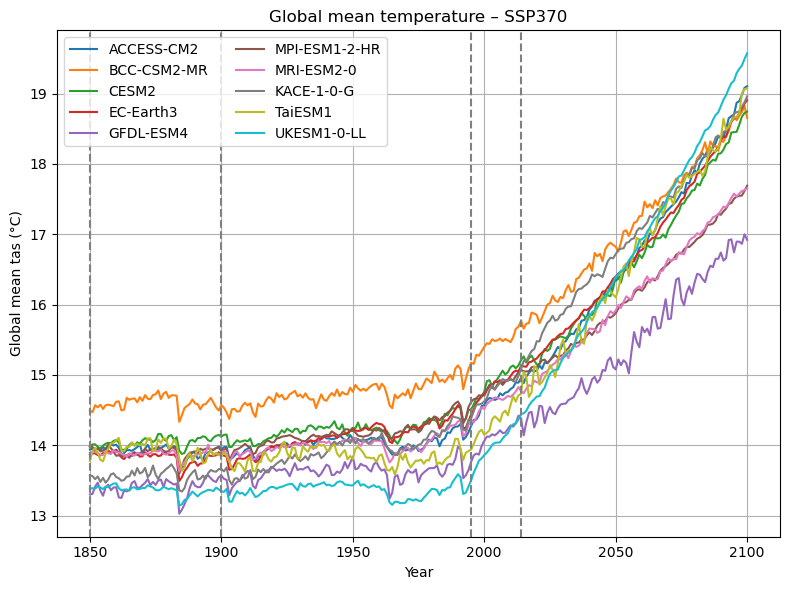

In [32]:

plt.figure(figsize=(8, 6))

for esm in final_ds_combined.data_vars:
    final_ds_combined[esm].plot(label=esm)

plt.axvline(x=1850, linestyle='--', color='grey')
plt.axvline(x=1900, linestyle='--', color='grey')
plt.axvline(x=1995, linestyle='--', color='grey')
plt.axvline(x=2014, linestyle='--', color='grey')

plt.legend(ncol=2)
plt.xlabel("Year")
plt.ylabel("Global mean tas (°C)")
plt.title("Global mean temperature – SSP370")

plt.tight_layout()
plt.grid()

plt.show()


In [43]:
# Adjust the timeseries to show the change relative to the 2015-2024 baseline
final_ds_adjusted = xr.Dataset()
for esm in final_ds_combined.data_vars:
    da = final_ds_combined[esm]
    baseline = da.sel(time=slice(2015, 2024)).mean(dim="time")
    da_adjusted = da - baseline + 1.2534583333333331
    final_ds_adjusted[esm] = da_adjusted

In [44]:
final_ds_adjusted

<xarray.Dataset> Size: 22kB
Dimensions:        (time: 251)
Coordinates:
  * time           (time) int64 2kB 1850 1851 1852 1853 ... 2097 2098 2099 2100
Data variables:
    ACCESS-CM2     (time) float64 2kB 0.1287 0.1415 0.1169 ... 5.168 5.269 5.293
    BCC-CSM2-MR    (time) float64 2kB -0.07086 -0.09599 0.002758 ... 4.259 4.085
    CESM2          (time) float64 2kB -0.01546 0.01998 0.02056 ... 4.732 4.75
    EC-Earth3      (time) float64 2kB -0.1226 -0.1023 -0.1018 ... 4.87 4.918
    GFDL-ESM4      (time) float64 2kB 0.165 0.1726 0.2766 ... 3.727 3.862 3.783
    MPI-ESM1-2-HR  (time) float64 2kB 0.1157 0.1038 0.06332 ... 3.744 3.818
    MRI-ESM2-0     (time) float64 2kB 0.2432 0.2477 0.2557 ... 3.964 3.975 4.003
    KACE-1-0-G     (time) float64 2kB -0.6055 -0.617 -0.6602 ... 4.695 4.778
    TaiESM1        (time) float64 2kB 0.08845 0.2306 0.2732 ... 5.31 5.375 5.381
    UKESM1-0-LL    (time) float64 2kB -0.03076 -0.02524 -0.0306 ... 6.076 6.156

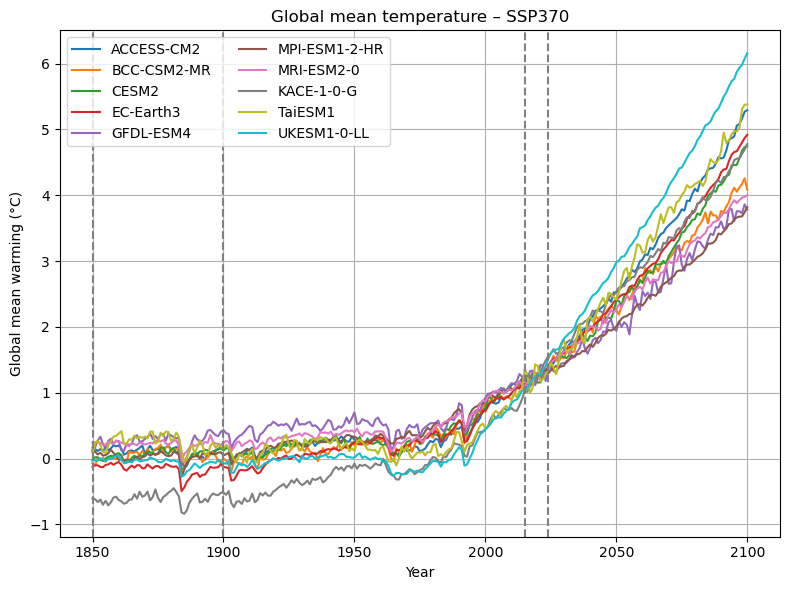

In [45]:

plt.figure(figsize=(8, 6))

for esm in final_ds_adjusted.data_vars:
    final_ds_adjusted[esm].plot(label=esm)
plt.axvline(x=1850, linestyle='--', color='grey')
plt.axvline(x=1900, linestyle='--', color='grey')
plt.axvline(x=2015, linestyle='--', color='grey')
plt.axvline(x=2024, linestyle='--', color='grey')
xmin, xmax = plt.gca().get_xlim()
plt.axhline(y=1.2534583333333331, xmin=(2015 - xmin) / (xmax - xmin), xmax=(2024 - xmin) / (xmax - xmin), linestyle='--', color='grey')


plt.legend(ncol=2)
plt.xlabel("Year")
plt.ylabel("Global mean warming (°C)")
plt.title("Global mean temperature – SSP370")

plt.tight_layout()
plt.grid()

plt.show()


In [46]:
final_ds_adjusted

# Calculate a running mean of 10 years for each ESM
final_ds_adj_running_mean = final_ds_adjusted.rolling(time=10, center=True).mean()
# final_ds_running_mean

In [47]:
# Determine when each ESM reaches 2.0°C warming above pre-industrial levels
threshold = 2.0
warming_thresholds = pd.DataFrame(columns=['ESM', 'Year_reached_2C'])
for esm in final_ds_adj_running_mean.data_vars:
    ds_esm = final_ds_adj_running_mean[esm]
    years_above_threshold = ds_esm.time.where(ds_esm >= threshold, drop=True).min().item()
    warming_thresholds = pd.concat(
        [warming_thresholds,
        pd.DataFrame([{'ESM': esm, 'Year_reached_2C': int(years_above_threshold)}])],
        ignore_index=True
    )
warming_thresholds

,ESM,Year_reached_2C
0,ACCESS-CM2,2039
1,BCC-CSM2-MR,2042
2,CESM2,2044
3,EC-Earth3,2042
4,GFDL-ESM4,2050
5,MPI-ESM1-2-HR,2050
6,MRI-ESM2-0,2043
7,KACE-1-0-G,2037
8,TaiESM1,2040
9,UKESM1-0-LL,2035


In [50]:
# Determine when each ESM reaches 2.0°C warming above pre-industrial levels
threshold = 2.0
warming_thresholds = pd.DataFrame(columns=['ESM', 'Year_reached_2C'])
for esm in final_ds_adj_running_mean.data_vars:
    ds_esm = final_ds_adj_running_mean[esm]
    years_above_threshold = ds_esm.time.where(ds_esm >= threshold, drop=True).min().item()
    warming_thresholds = pd.concat(
        [warming_thresholds,
        pd.DataFrame([{'ESM': esm, 'Year_reached_2C': int(years_above_threshold)}])],
        ignore_index=True
    )
warming_thresholds

,ESM,Year_reached_2C
0,ACCESS-CM2,2039
1,BCC-CSM2-MR,2042
2,CESM2,2044
3,EC-Earth3,2042
4,GFDL-ESM4,2050
5,MPI-ESM1-2-HR,2050
6,MRI-ESM2-0,2043
7,KACE-1-0-G,2037
8,TaiESM1,2040
9,UKESM1-0-LL,2035


### Other way to calculate the same thing

In [ ]:
# Calculate warming periods for different timespans (1850-1900, 2015-2024)
mean_2015_2024 = {}
mean_1850_1900 = {}
preindustrial = {}
for esm in final_ds_combined.data_vars:
    ds_esm = final_ds_combined[esm]
    mean_2015_2024[esm] = ds_esm.sel(time=slice(2015, 2024)).mean().item()
    mean_1850_1900[esm] = ds_esm.sel(time=slice(1850, 1900)).mean().item()
    preindustrial[esm] = ds_esm.sel(time=slice(2015, 2024)).mean().item() - 1.2534583333333331

preindustrial

{'ACCESS-CM2': 13.814171800908937,
 'BCC-CSM2-MR': 14.56962514090468,
 'CESM2': 13.99652081460052,
 'EC-Earth3': 13.990721696622895,
 'GFDL-ESM4': 13.140232967915557,
 'MPI-ESM1-2-HR': 13.87422849831296,
 'MRI-ESM2-0': 13.655149321220568,
 'KACE-1-0-G': 14.18293961664395,
 'TaiESM1': 13.692809486741528,
 'UKESM1-0-LL': 13.41857130168808}

In [20]:
# Calculate a running mean of 10 years for each ESM
final_ds_running_mean = final_ds_combined.rolling(time=10, center=True).mean()
# final_ds_running_mean

In [52]:
ds_era5_gmt_adjusted

13.488343270312582

In [21]:
# Determine when each ESM reaches 2.0°C warming above pre-industrial levels
threshold = 2.0
# warming_thresholds = pd.DataFrame(columns=['ESM', 'Year_reached_2C', 'Absolute_Temp_in_Year_reached_2C',
#                                            'Preindustrial_Temp', 'Year_reached_ERA5_threshold',
#                                            'Temp_over_ERA5_threshold'])
warming_thresholds = pd.DataFrame(columns=['ESM', 'Year_reached_2C', 'Absolute_Temp_in_Year_reached_2C',
                                           'Preindustrial_Temp'])
for esm in final_ds_running_mean.data_vars:
    ds_esm = final_ds_running_mean[esm]
    pi_temp = preindustrial[esm]
    
    target_temp = pi_temp + threshold
    years_above_threshold = ds_esm.time.where(ds_esm >= target_temp, drop=True).min().item()
    # years_above_ERA5_threshold = ds_esm.time.where(ds_esm >= ds_era5_gmt_adjusted + threshold, drop=True).min().item()

    warming_thresholds = pd.concat(
        [warming_thresholds,
        pd.DataFrame([{'ESM': esm, 'Year_reached_2C': int(years_above_threshold),
                       'Absolute_Temp_in_Year_reached_2C': float(ds_esm.sel(time=years_above_threshold)),
                       'Preindustrial_Temp': float(pi_temp),
                       #'Year_reached_ERA5_threshold': int(years_above_ERA5_threshold),
                       #'Temp_over_ERA5_threshold': float(ds_esm.sel(time=years_above_ERA5_threshold))
                       }])],
        ignore_index=True
    )
warming_thresholds

/tmp/ipykernel_2414932/2627880673.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  warming_thresholds = pd.concat(


,ESM,Year_reached_2C,Absolute_Temp_in_Year_reached_2C,Preindustrial_Temp
0,ACCESS-CM2,2039,15.829328,13.814172
1,BCC-CSM2-MR,2042,16.605910,14.569625
2,CESM2,2044,16.003576,13.996521
3,EC-Earth3,2042,16.024789,13.990722
4,GFDL-ESM4,2050,15.151119,13.140233
5,MPI-ESM1-2-HR,2050,15.885779,13.874228
6,MRI-ESM2-0,2043,15.659036,13.655149
7,KACE-1-0-G,2037,16.196605,14.182940
8,TaiESM1,2040,15.746470,13.692809
9,UKESM1-0-LL,2035,15.469428,13.418571


In [22]:
# Save warming_thresholds to a file
warming_thresholds.to_csv('/home/onennecke/CMIP_models/warming_thresholds.csv', index=False)

In [23]:
# Teststuff
# Select a ten year time period for a single model 2040-2049
final_ds_combined['ACCESS-CM2'].sel(time=slice('2033-01-01', '2043-12-31'))

<xarray.DataArray 'ACCESS-CM2' (time: 10)> Size: 80B
array([15.5799808 , 15.64840189, 15.670125  , 15.76981017, 15.78039476,
       15.82415341, 15.92803014, 15.97034989, 16.05649203, 16.06554528])
Coordinates:
  * time     (time) int64 80B 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043

### Test results

In [35]:
warming_thresholds.loc[warming_thresholds["ESM"] == "BCC-CSM2-MR", "Year_reached_2C"].values[0]


2042

In [36]:
x = 2042
print(final_ds_combined['BCC-CSM2-MR'].sel(time=slice(warming_thresholds.loc[warming_thresholds["ESM"] == "BCC-CSM2-MR", "Year_reached_2C"].values[0]-5, warming_thresholds.loc[warming_thresholds["ESM"] == "BCC-CSM2-MR", "Year_reached_2C"].values[0]+5)).mean().item())
print(preindustrial['BCC-CSM2-MR'])
print(final_ds_combined['BCC-CSM2-MR'].sel(time=slice(warming_thresholds.loc[warming_thresholds["ESM"] == "BCC-CSM2-MR", "Year_reached_2C"].values[0]-5, warming_thresholds.loc[warming_thresholds["ESM"] == "BCC-CSM2-MR", "Year_reached_2C"].values[0]+5)).mean().item() - preindustrial['BCC-CSM2-MR'])

16.6277669789868
14.56962514090468
2.0581418380821184


In [59]:
preindustrial['ACCESS-CM2']

13.807900125024446

## Not so important

In [28]:
# Calculate warming periods for different timespans (1850-1900, 1995-2014)
warming_periods = {}
for esm in final_ds_combined.data_vars:
    ds_esm = final_ds_combined[esm]
    mean_1850_1900 = ds_esm.sel(time=slice(1850, 1900)).mean().item()
    mean_1995_2014 = ds_esm.sel(time=slice(1995, 2014)).mean().item()
    warming = mean_1995_2014 - mean_1850_1900
    warming_periods[esm] = warming
    
warming_periods

{'ACCESS-CM2': 0.7378654892559542,
 'BCC-CSM2-MR': 0.8487771241142728,
 'CESM2': 0.8597126366737395,
 'EC-Earth3': 1.0085300772171806,
 'GFDL-ESM4': 0.7202285208022285,
 'MPI-ESM1-2-HR': 0.9294217085650249,
 'MRI-ESM2-0': 0.7371500194903433,
 'KACE-1-0-G': 1.209103981873037,
 'TaiESM1': 0.4281303797930818,
 'UKESM1-0-LL': 0.652073433283503}

In [36]:
# Calcualte the difference of preindustrial and 1850-1900 mean temperatures
preindustrial_diff = {}
for esm in final_ds_combined.data_vars:
    preindustrial_diff[esm] = preindustrial[esm] - mean_1850_1900[esm]
    
preindustrial_diff

{'ACCESS-CM2': -0.11213451074404546,
 'BCC-CSM2-MR': -0.0012228758857268929,
 'CESM2': 0.009712636673739894,
 'EC-Earth3': 0.15853007721718093,
 'GFDL-ESM4': -0.1297714791977711,
 'MPI-ESM1-2-HR': 0.07942170856502528,
 'MRI-ESM2-0': -0.11284998050965633,
 'KACE-1-0-G': 0.35910398187303727,
 'TaiESM1': -0.4218696202069179,
 'UKESM1-0-LL': -0.19792656671649667}

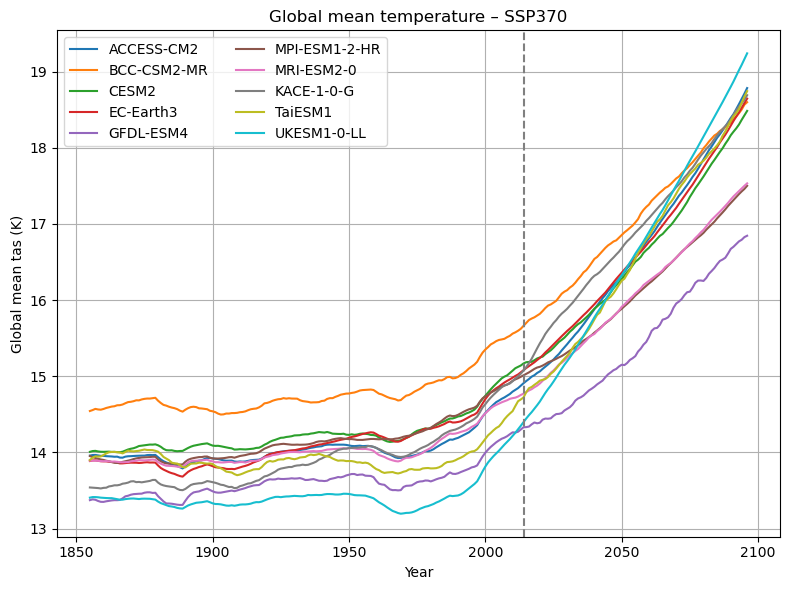

In [27]:

plt.figure(figsize=(8, 6))

for esm in final_ds_running_mean.data_vars:
    final_ds_running_mean[esm].plot(label=esm)
plt.axvline(x=2014, linestyle='--', color='grey')

plt.legend(ncol=2)
plt.xlabel("Year")
plt.ylabel("Global mean tas (K)")
plt.title("Global mean temperature – SSP370")

plt.tight_layout()
plt.grid()

plt.show()